# ML Engineering Portfolio — Walkthrough

Methodology demonstrations on synthetic data for the production-ML concerns that decide whether a model that looks good offline holds up live. Each result is measured out-of-sample and reported as mean ± std across seeds.

**Author:** Kyle Reynolds

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('../src'))
from IPython.display import Image

## 1 · Leakage-safe time-series validation

A controlled comparison: both schemes train on the **same number of rows** — only *which* rows differ. Training on the test block's own era (including future-adjacent rows) inflates the AUC versus an honest past-only model.

In [2]:
import walk_forward_validation as wfv
r = wfv.evaluate()
print(f"Leakage (test-era + future) AUC : {r['leak_mean']:.3f} ± {r['leak_std']:.3f}")
print(f"Time-respecting (past) AUC      : {r['trust_mean']:.3f} ± {r['trust_std']:.3f}")
print(f"Temporal-validation optimism    : {r['optimism_mean']:+.3f} ± {r['optimism_std']:.3f}")

Leakage (test-era + future) AUC : 0.852 ± 0.005
Time-respecting (past) AUC      : 0.840 ± 0.005
Temporal-validation optimism    : +0.012 ± 0.002


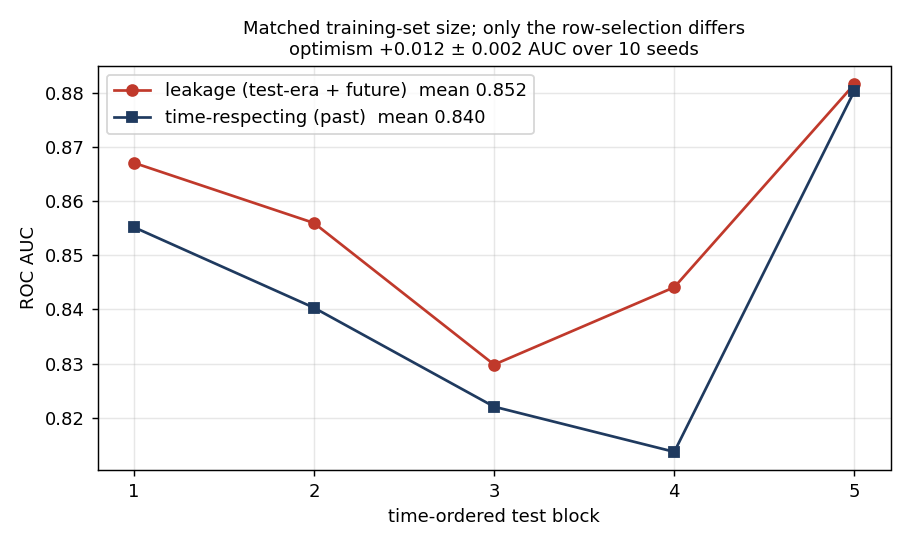

In [3]:
Image('../images/walk_forward_validation.png')

## 2 · Probability calibration

Isotonic calibration lowers the Brier score; because it's monotone the ranking is *nearly* unchanged — we **measure** the AUC change rather than assume it.

In [4]:
import probability_calibration as cal
r = cal.evaluate()
print(f"Brier uncalibrated : {r['brier_uncal_mean']:.4f} ± {r['brier_uncal_std']:.4f}")
print(f"Brier calibrated   : {r['brier_cal_mean']:.4f} ± {r['brier_cal_std']:.4f}")
print(f"AUC {r['auc_uncal_mean']:.4f} -> {r['auc_cal_mean']:.4f} "
      f"(max |change| {r['auc_delta_max_abs']:.5f})")

Brier uncalibrated : 0.0503 ± 0.0034
Brier calibrated   : 0.0454 ± 0.0032
AUC 0.9779 -> 0.9774 (max |change| 0.00107)


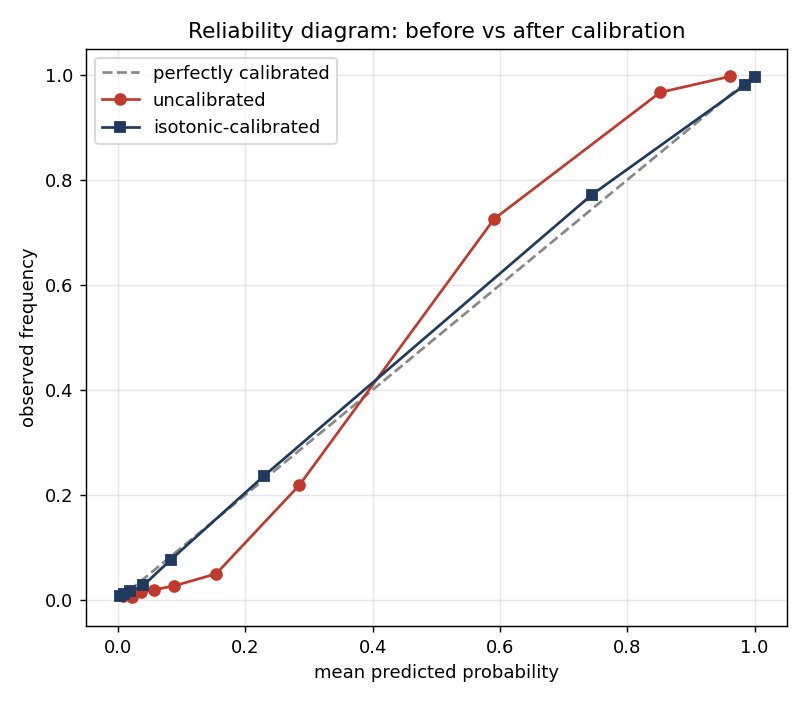

In [5]:
Image('../images/probability_calibration.png')

## 3 · SHAP-driven feature selection

Feature ranking and the count *k* are chosen on a **validation** split and reported once on an **untouched test** split — never selecting on the data you report. The selected features match the full model on test data within noise.

In [6]:
import shap_feature_selection as sfs
r = sfs.evaluate()
print(f"All {r['n_features']} features  test AUC : {r['full_test_mean']:.3f} ± {r['full_test_std']:.3f}")
print(f"Selected (median k={r['k_median']}) test AUC : {r['topk_test_mean']:.3f} ± {r['topk_test_std']:.3f}")

All 40 features  test AUC : 0.981 ± 0.007
Selected (median k=10) test AUC : 0.981 ± 0.006


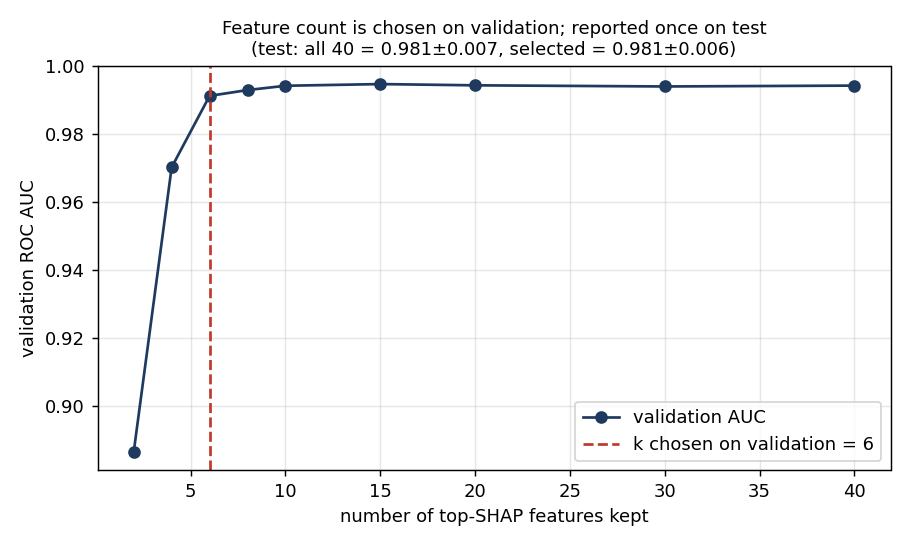

In [7]:
Image('../images/shap_feature_selection.png')

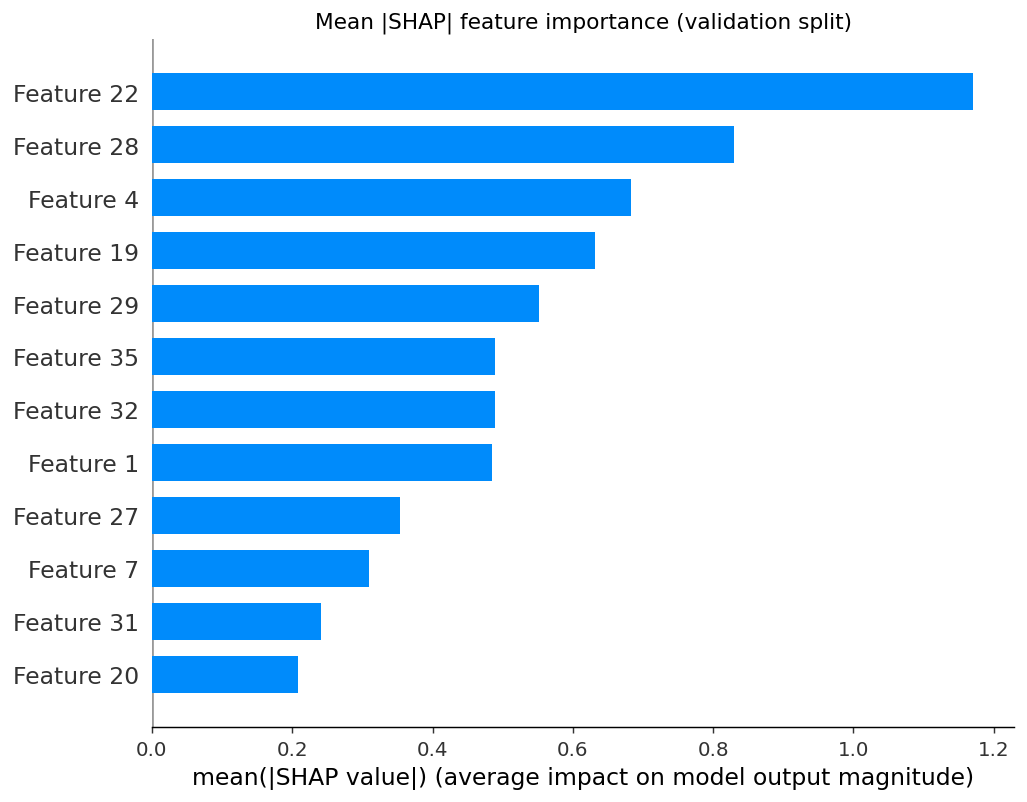

In [8]:
Image('../images/shap_importance.png')

## 4 · Feature drift detection

PSI and the KS test flag which features shifted. PSI bands are heuristics; the KS p-value is sample-size-driven, so the demo also reports the KS D-statistic. Input drift is an early warning — it triggers investigation, it doesn't by itself prove the model degraded.

In [9]:
import drift_detection as drift
r = drift.evaluate()
for name, psi in zip(r['names'], r['psi']):
    print(f"{name:<12} PSI {psi:6.3f}")
print('flagged:', ', '.join(r['flagged']))

feature_0    PSI  1.262
feature_1    PSI  0.003
feature_2    PSI  0.370
feature_3    PSI  0.004
feature_4    PSI  0.237
feature_5    PSI  0.003
flagged: feature_0, feature_2


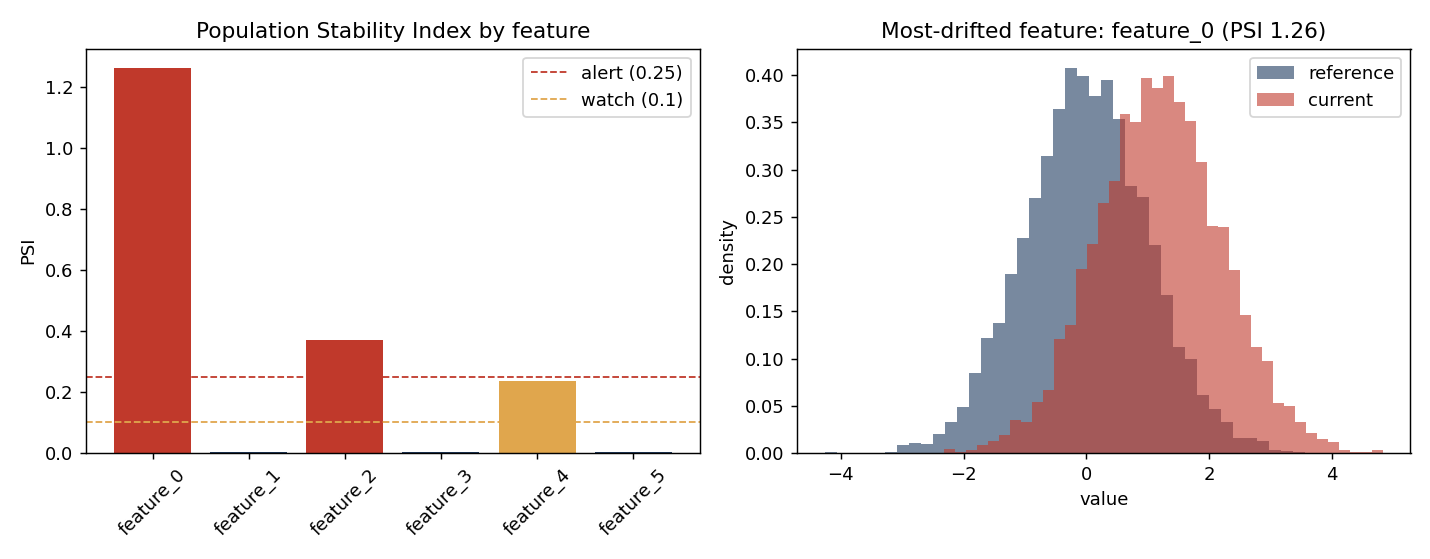

In [10]:
Image('../images/drift_detection.png')

---

Every result is deterministic per seed and reported across seeds. Reproduce with `python run_all.py`; the headline claims are asserted in `tests/` and run in CI.